In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import tensorflow as tf

In [3]:
glass = pd.read_csv('data/glass.data', names='RI Na Mg Al Si K Ca Ba Fe Type'.split())

In [4]:
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
1,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
2,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
3,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
4,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
5,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
glass.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [6]:
sns.set_theme(style='white',font_scale=2,palette='bright')

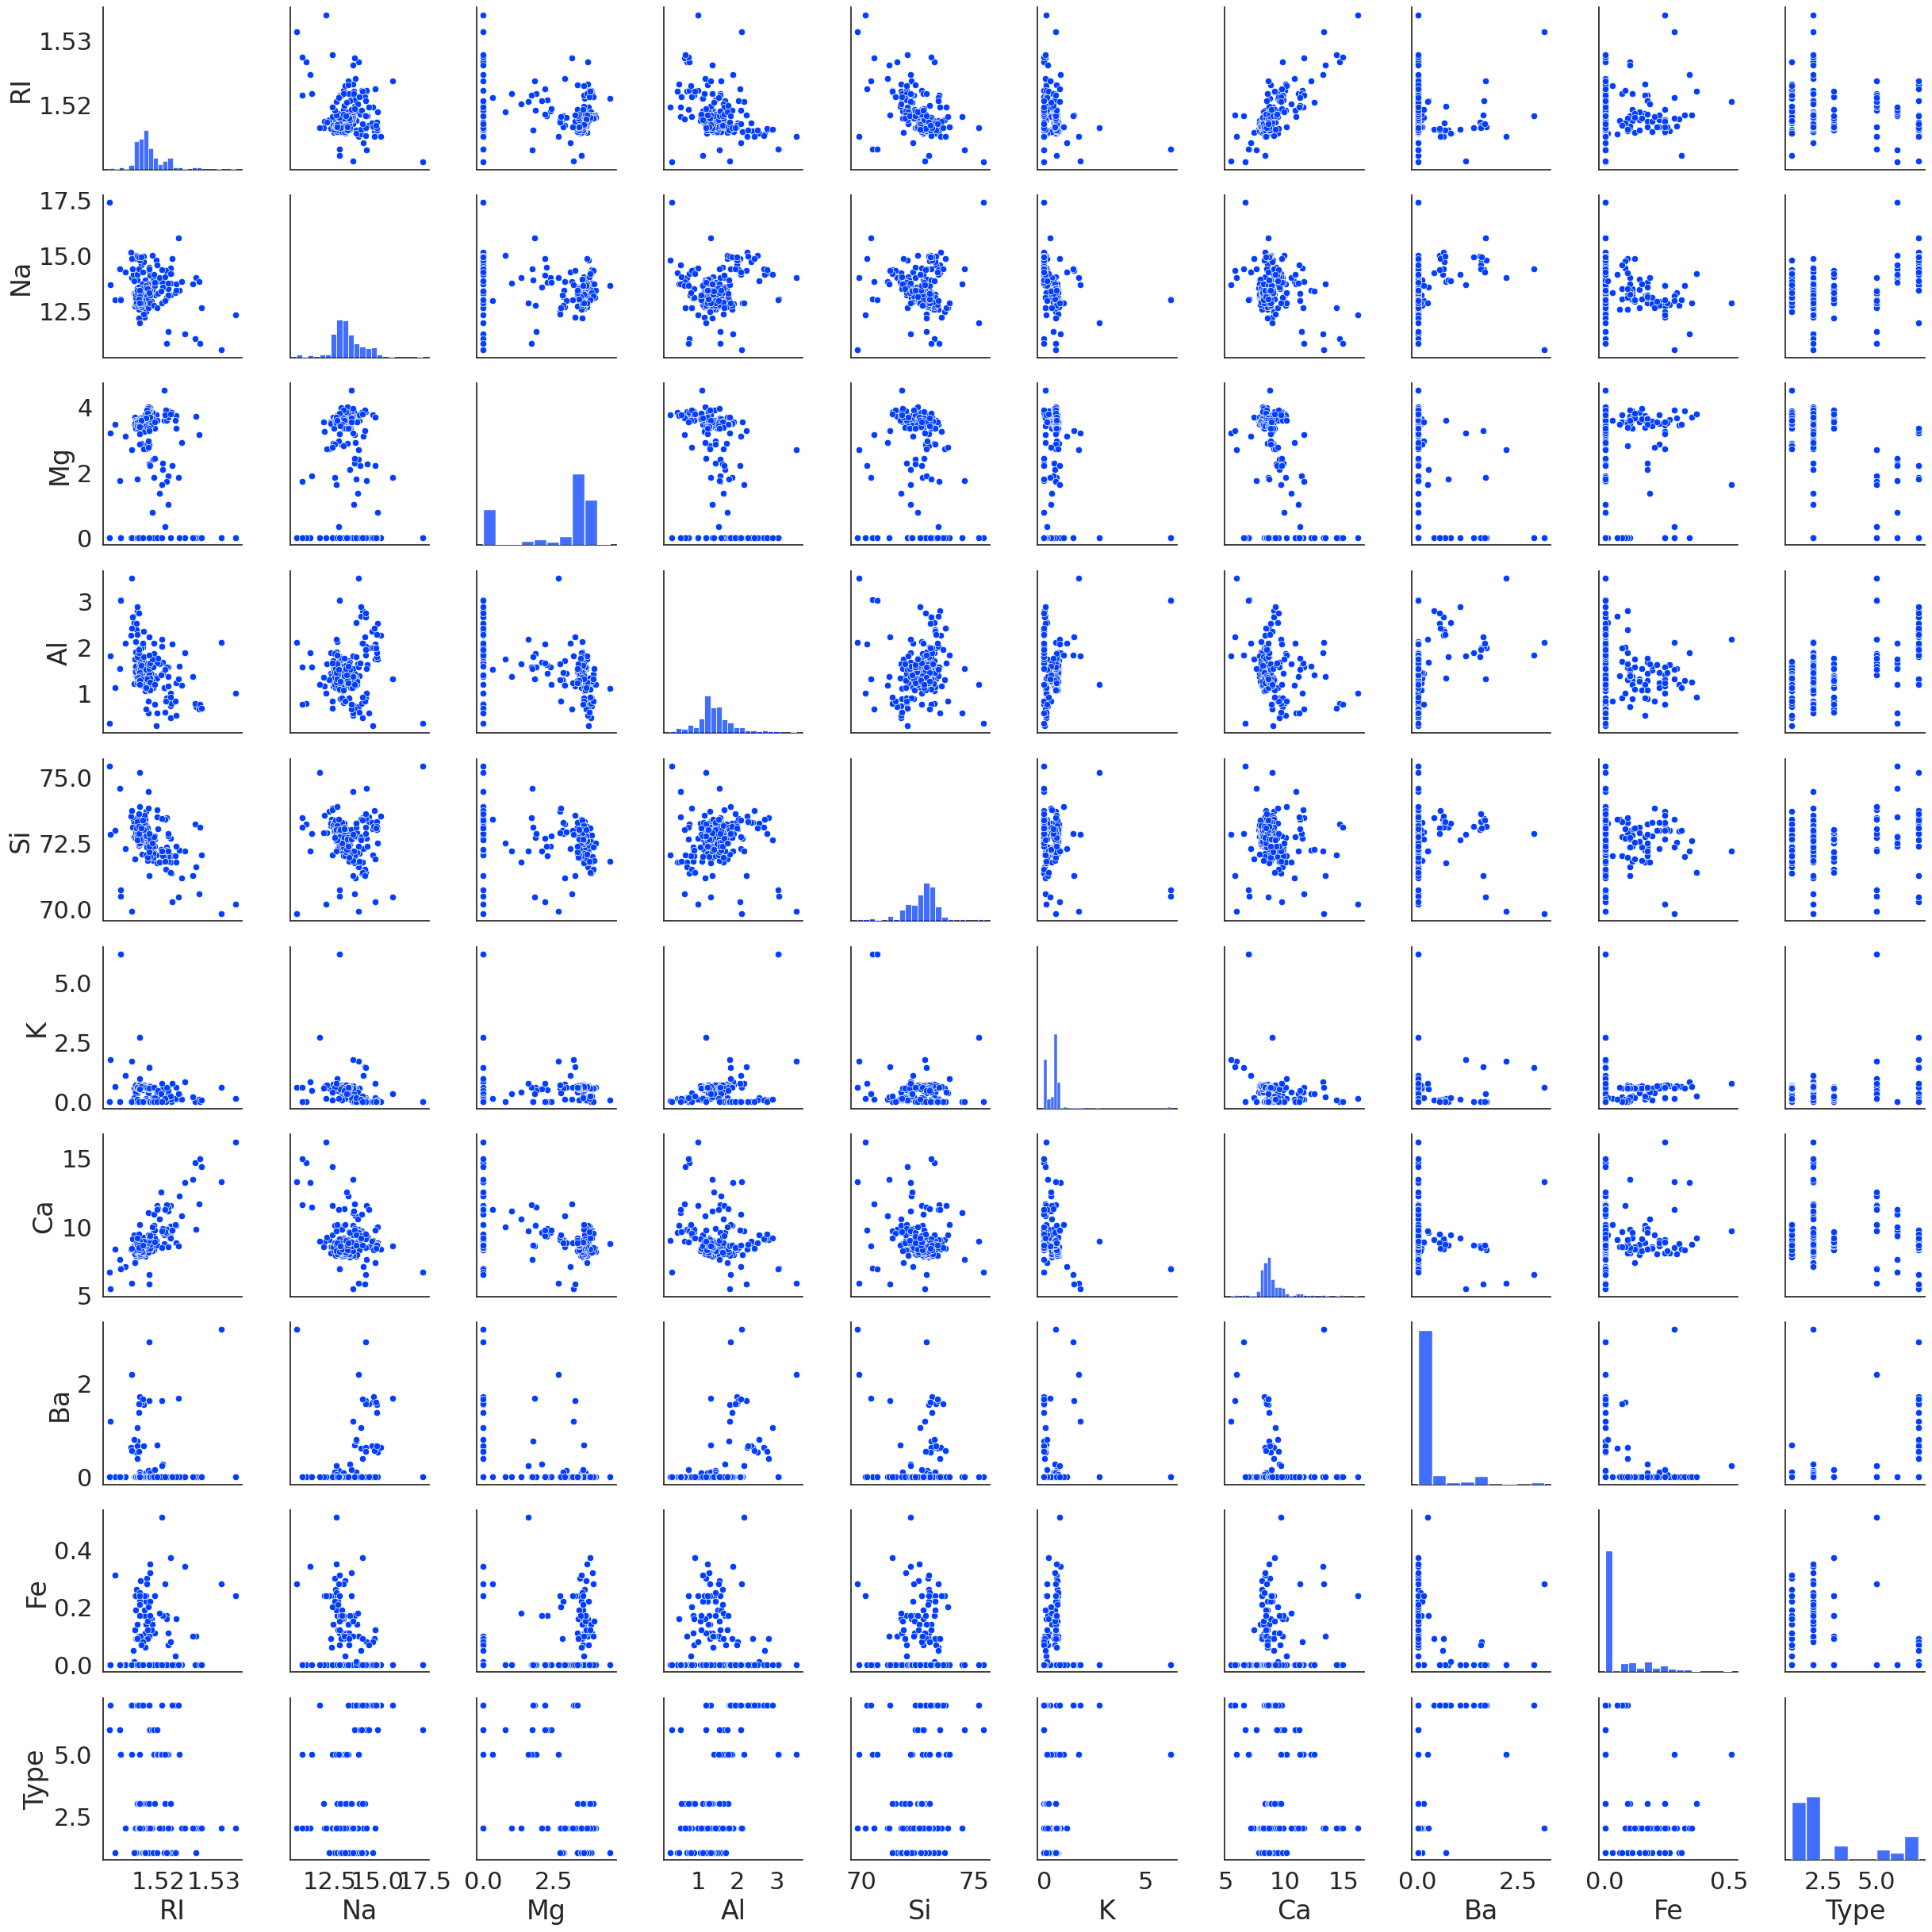

In [7]:
sns.pairplot(glass)

<Axes: xlabel='Na', ylabel='Probability'>

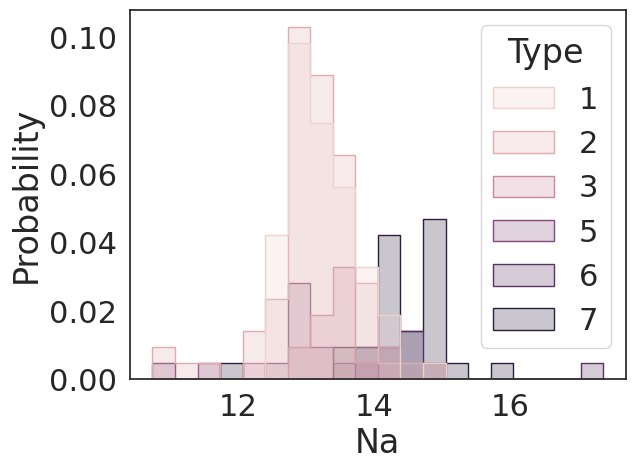

In [8]:
sns.histplot(data=glass, x='Na', hue='Type', element='step', stat='probability', bins=20)

<Axes: >

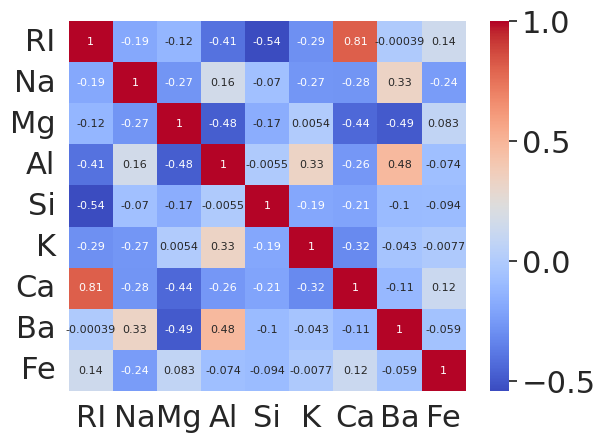

In [9]:
sns.heatmap(glass['RI Na Mg Al Si K Ca Ba Fe'.split()].corr(), cmap='coolwarm', annot=True, annot_kws={'size': 8})

In [10]:
X = glass['RI Na Mg Al Si K Ca Ba Fe'.split()]
Y = glass['Type']

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
lencoder = LabelEncoder()
lencoder.fit(Y_train)

ohencoder = OneHotEncoder()
ohencoder.fit(pd.DataFrame(lencoder.transform(Y_train)))

def ohe_encode(y):
    res = ohencoder.transform(pd.DataFrame(lencoder.transform(y))).toarray()
    return res

def ohe_decode(y):
    res = ohencoder.inverse_transform(y)
    #res = lencoder.inverse_transform(res)
    res = lencoder.inverse_transform(res.ravel())
    return res

In [13]:
model = LogisticRegression()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)
print("\nClassification Report:\n\n", classification_report(Y_test, Y_pred))


Classification Report:

               precision    recall  f1-score   support

           1       0.67      0.64      0.65        25
           2       0.58      0.69      0.63        26
           3       0.00      0.00      0.00         4
           5       1.00      0.33      0.50         6
           6       0.50      0.50      0.50         4
           7       0.77      1.00      0.87        10

    accuracy                           0.64        75
   macro avg       0.59      0.53      0.53        75
weighted avg       0.63      0.64      0.62        75



In [14]:
model = RandomForestClassifier()
model.fit(X_train_scaled, Y_train)
Y_pred = model.predict(X_test_scaled)
print("\nClassification Report:\n\n", classification_report(Y_test, Y_pred))


Classification Report:

               precision    recall  f1-score   support

           1       0.81      0.84      0.82        25
           2       0.80      0.77      0.78        26
           3       0.40      0.50      0.44         4
           5       1.00      0.50      0.67         6
           6       0.80      1.00      0.89         4
           7       0.91      1.00      0.95        10

    accuracy                           0.80        75
   macro avg       0.79      0.77      0.76        75
weighted avg       0.81      0.80      0.80        75



In [15]:
model = XGBClassifier()
model.fit(X_train_scaled, lencoder.transform(Y_train))
Y_pred = lencoder.inverse_transform(model.predict(X_test_scaled))
print("\nClassification Report:\n\n", classification_report(Y_test, Y_pred))


Classification Report:

               precision    recall  f1-score   support

           1       0.75      0.72      0.73        25
           2       0.67      0.69      0.68        26
           3       0.67      0.50      0.57         4
           5       0.60      0.50      0.55         6
           6       0.80      1.00      0.89         4
           7       0.91      1.00      0.95        10

    accuracy                           0.73        75
   macro avg       0.73      0.74      0.73        75
weighted avg       0.73      0.73      0.73        75



In [16]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(6, activation='relu'))
model.add(tf.keras.layers.Dense(6, activation='relu'))
model.add(tf.keras.layers.Dense(6, activation='softmax'))
model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='adam')
model.fit(X_train_scaled, ohe_encode(Y_train), batch_size=32, epochs=100, verbose=False)
Y_pred=ohe_decode(model.predict(X_test_scaled, verbose=False))
print("\nClassification Report:\n\n", classification_report(np.array(Y_test), Y_pred))


Classification Report:

               precision    recall  f1-score   support

           1       0.61      0.68      0.64        25
           2       0.55      0.69      0.61        26
           3       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         6
           6       0.00      0.00      0.00         4
           7       0.64      0.90      0.75        10

    accuracy                           0.59        75
   macro avg       0.30      0.38      0.33        75
weighted avg       0.48      0.59      0.53        75



In [17]:
accuracy_lr = np.array([])
accuracy_rf = np.array([])
accuracy_xb = np.array([])
accuracy_nn = np.array([])

rnd = np.random.randint(1000, high=100000, size=50)
for i in np.arange(rnd.size):
    #print(f"Iter {i}")

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.35, random_state=rnd[i])

    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lencoder = LabelEncoder()
    lencoder.fit(Y_train)

    ohencoder = OneHotEncoder()
    ohencoder.fit(pd.DataFrame(lencoder.transform(Y_train)))

    def ohe_encode(y):
        res = ohencoder.transform(pd.DataFrame(lencoder.transform(y))).toarray()
        return res

    def ohe_decode(y):
        res = ohencoder.inverse_transform(y)
        #res = lencoder.inverse_transform(res)
        res = lencoder.inverse_transform(res.ravel())
        return res


    # logistic regression
    model = LogisticRegression()
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    accuracy_lr = np.append(accuracy_lr, accuracy_score(Y_test, Y_pred))

    # random forest
    model = RandomForestClassifier()
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)
    accuracy_rf = np.append(accuracy_rf, accuracy_score(Y_test, Y_pred))
    
    # xgboost
    model = XGBClassifier()
    model.fit(X_train_scaled, lencoder.transform(Y_train))
    Y_pred = lencoder.inverse_transform(model.predict(X_test_scaled))
    accuracy_xb = np.append(accuracy_xb, accuracy_score(Y_test, Y_pred))

    # neural network
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Dense(6, activation='relu'))
    model.add(tf.keras.layers.Dense(6, activation='relu'))
    model.add(tf.keras.layers.Dense(6, activation='softmax'))
    model.compile(loss=tf.keras.losses.categorical_crossentropy, optimizer='adam')
    model.fit(X_train_scaled, ohe_encode(Y_train), batch_size=32, epochs=100, verbose=False)
    Y_pred=ohe_decode(model.predict(X_test_scaled, verbose=False))
    accuracy_nn = np.append(accuracy_nn, accuracy_score(Y_test, Y_pred))


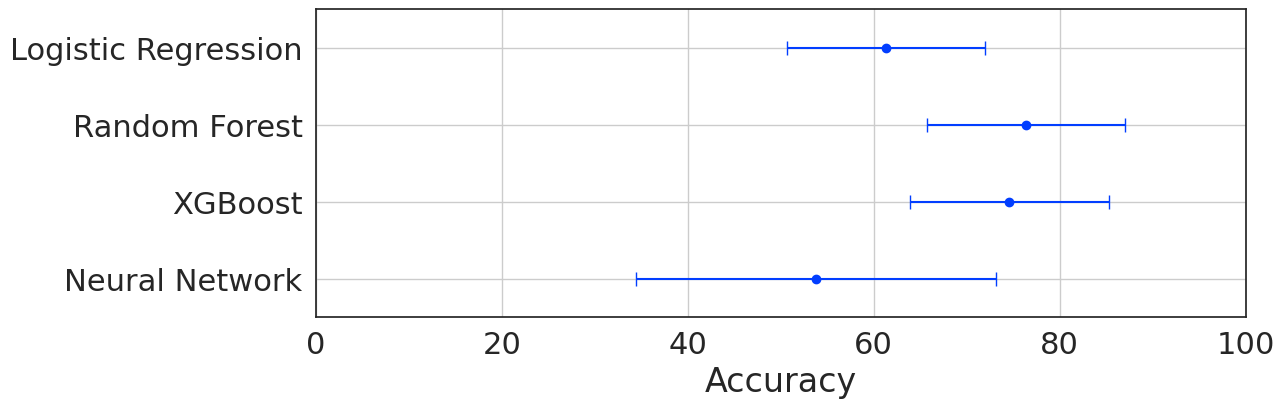

In [18]:
acc_mu = np.array([])
acc_err = np.array([])

for acc in [accuracy_lr, accuracy_rf, accuracy_xb, accuracy_nn]:
    acc = 100*acc
    acc_mu = np.append( acc_mu, np.mean(acc) )
    acc_err = np.append( acc_err, 0.5*(np.max(acc)-np.min(acc)) )

plt.figure(figsize=(12,4))
#plt.errorbar(acc_mu, ['Logistic Regression','Random Forest','XGBoost','Neural Network'], xerr=acc_err, ls='', marker='o', capsize=5)
plt.errorbar(np.flip(acc_mu), np.flip(['Logistic Regression','Random Forest','XGBoost','Neural Network']), xerr=np.flip(acc_err), ls='', marker='o', capsize=5)
plt.xlim(0,100)
plt.ylim(-0.5,3.5)
plt.xlabel('Accuracy')
plt.grid()